<a href="https://colab.research.google.com/github/saadi223/AI-based-blood_damage_model/blob/main/blood_damage_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Damage Prediction Model: A Machine Learning Approach

## 1. Data Loading and Initial Inspection

This section loads the dataset into a Pandas DataFrame and performs an initial inspection to understand its structure, size, and the first few entries. This is a crucial first step in any data science project to familiarize ourselves with the data we'll be working with.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('FYP_Physics_Informed_Dataset.csv')

print("Data shape (Rows, Columns):", df.shape)
display(df.head()) # Display the first 5 rows

Data shape (Rows, Columns): (427, 15)


,device_type,flow_rate_ml_min,inlet_diameter_mm,vol_avg_shear_rate,max_wall_shear_rate,p95_wall_shear_rate,throat_avg_shear_rate,vol_avg_exposure_time,max_exposure_time,throat_exposure_time,hydraulic_diameter_mm,target_log10_hi,vol_physics_index,throat_physics_index,max_physics_index
0,baseline,10,1.6,31.976647,3829.154433,3570.107782,154.259711,9.590000e-11,1.610000e-07,5.010000e-16,2.08,-10.364940,9.810000e-08,1.190000e-11,2.360650
1,baseline,11,1.6,35.177363,4212.620047,3927.118185,169.648624,8.760000e-11,1.470000e-07,5.010000e-16,2.08,-10.325546,1.080000e-07,1.440000e-11,2.608687
2,baseline,12,1.6,38.378858,4596.085662,4284.128589,185.037537,8.060000e-11,1.340000e-07,6.300000e-11,2.08,-10.264360,1.190000e-07,2.160000e-06,2.830616
3,baseline,13,1.6,41.580130,4979.550027,4641.140242,200.447830,7.470000e-11,1.430000e-07,5.830000e-11,2.08,-10.216936,1.290000e-07,2.340000e-06,3.545816
4,baseline,14,1.6,44.782628,5363.051879,4998.150645,215.845651,6.950000e-11,1.590000e-07,5.420000e-11,2.08,-10.164675,1.390000e-07,2.530000e-06,4.573210


### 1.1 Initial Data Overview

After loading the dataset, it's essential to get a quick overview. This typically involves checking the dimensions of the dataset (number of rows and columns) and displaying the first few rows to understand the features (columns) and the type of data they contain. This helps in identifying potential issues like missing values, incorrect data types, or outliers early on.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribution of Numerical Features

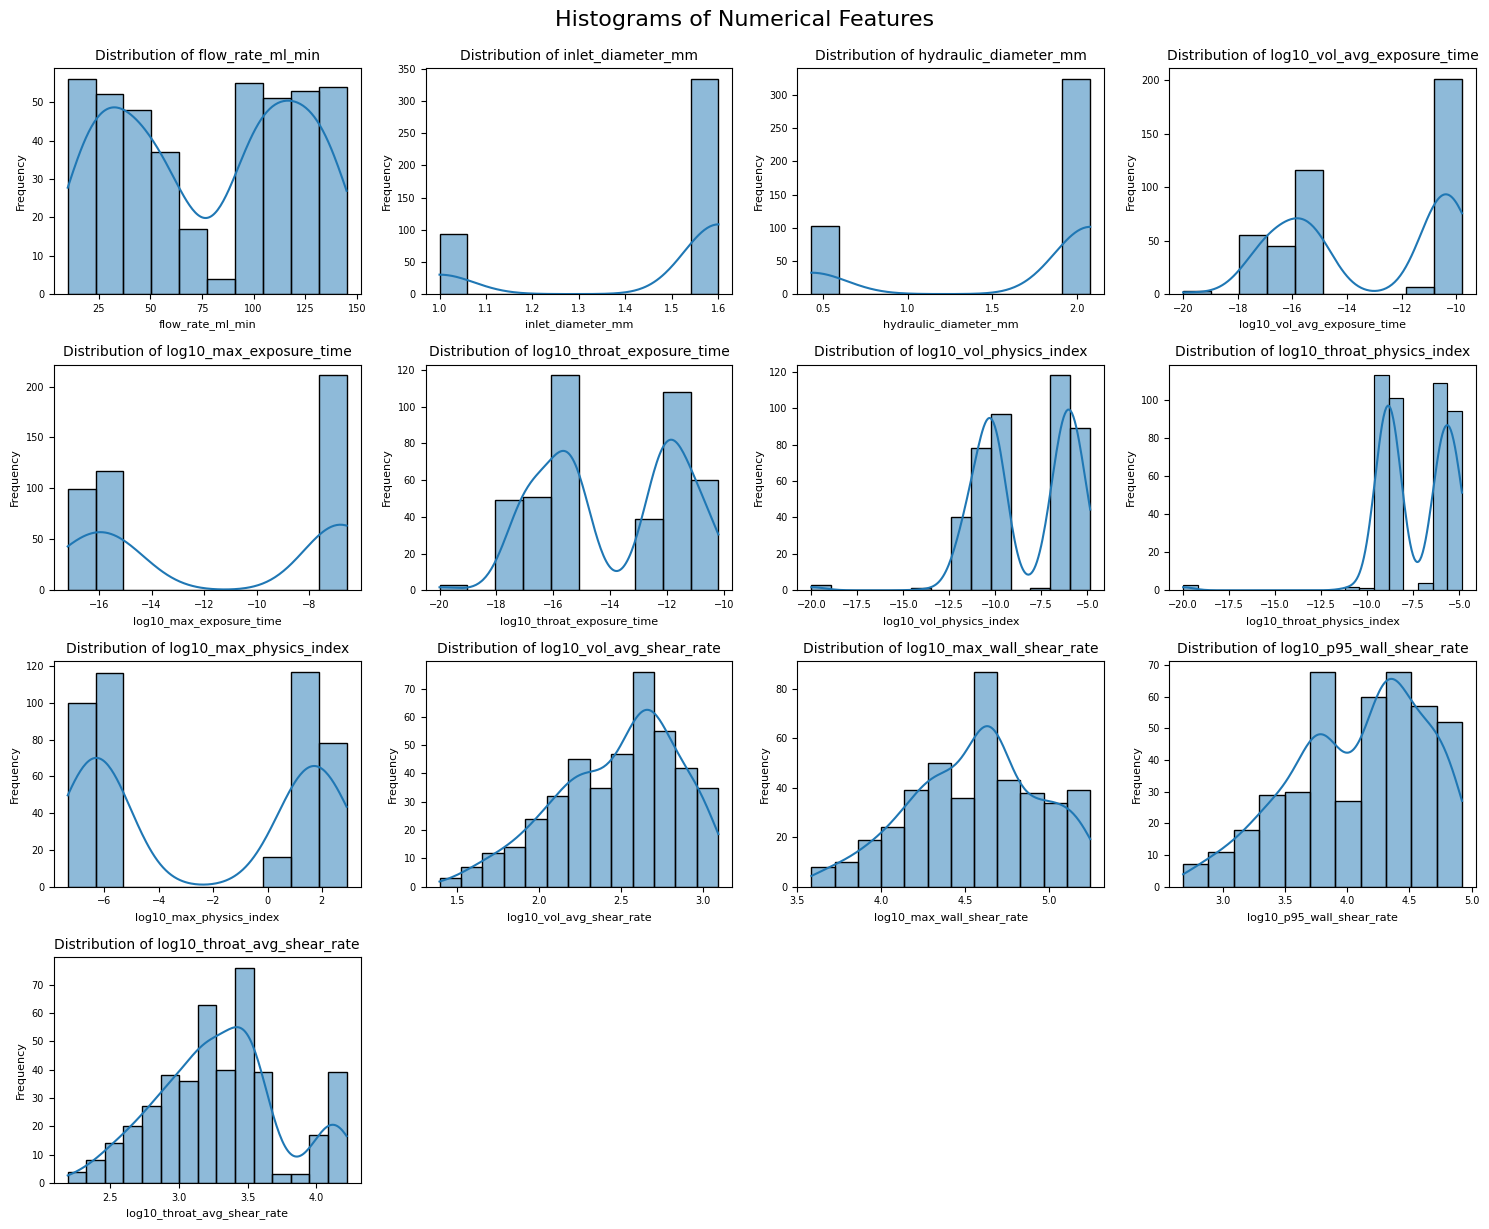

In [23]:
# Get all numerical columns (excluding the target and one-hot encoded device types if they are still present as separate columns after the previous steps)
numerical_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust subplot grid based on number of numerical features
    sns.histplot(X[col], kde=True) # Use X dataframe for features
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel(col, fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.show()

### 2.2 Correlation Matrix and Heatmap

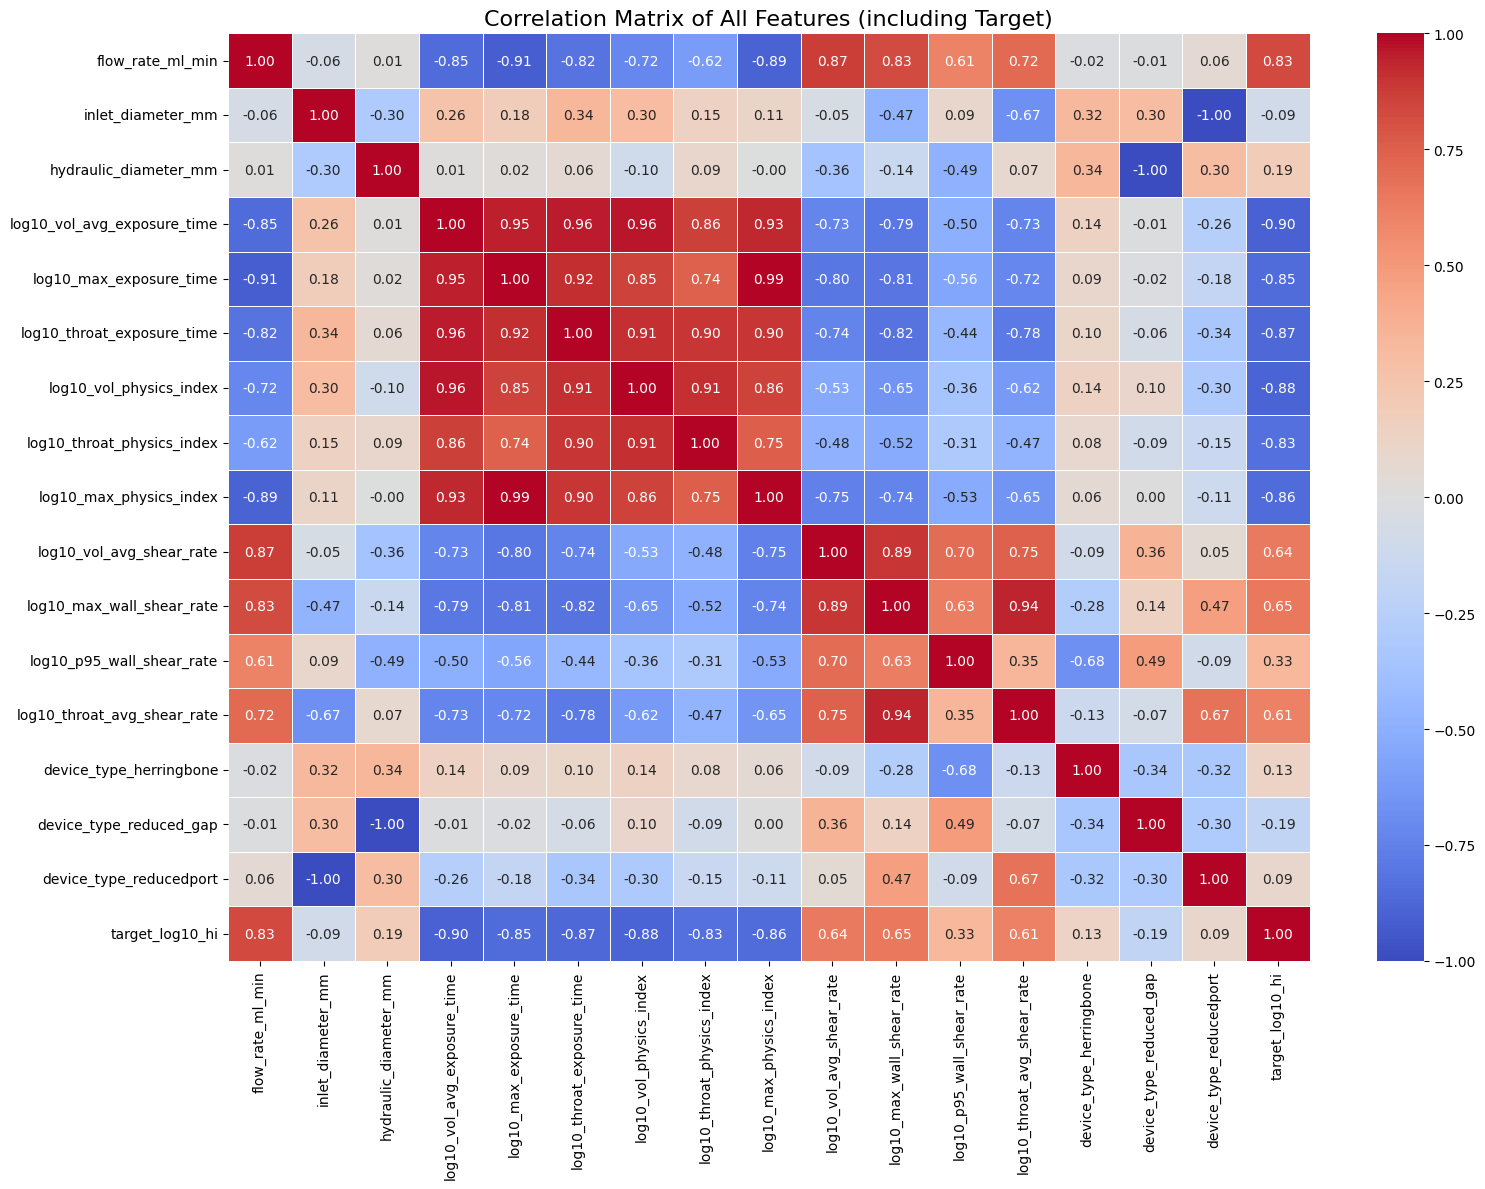

In [24]:
# Combine X (features) and y (target) back for correlation analysis
df_eda = pd.concat([X, y], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_eda.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (including Target)', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 Feature vs. Target Relationship Plots

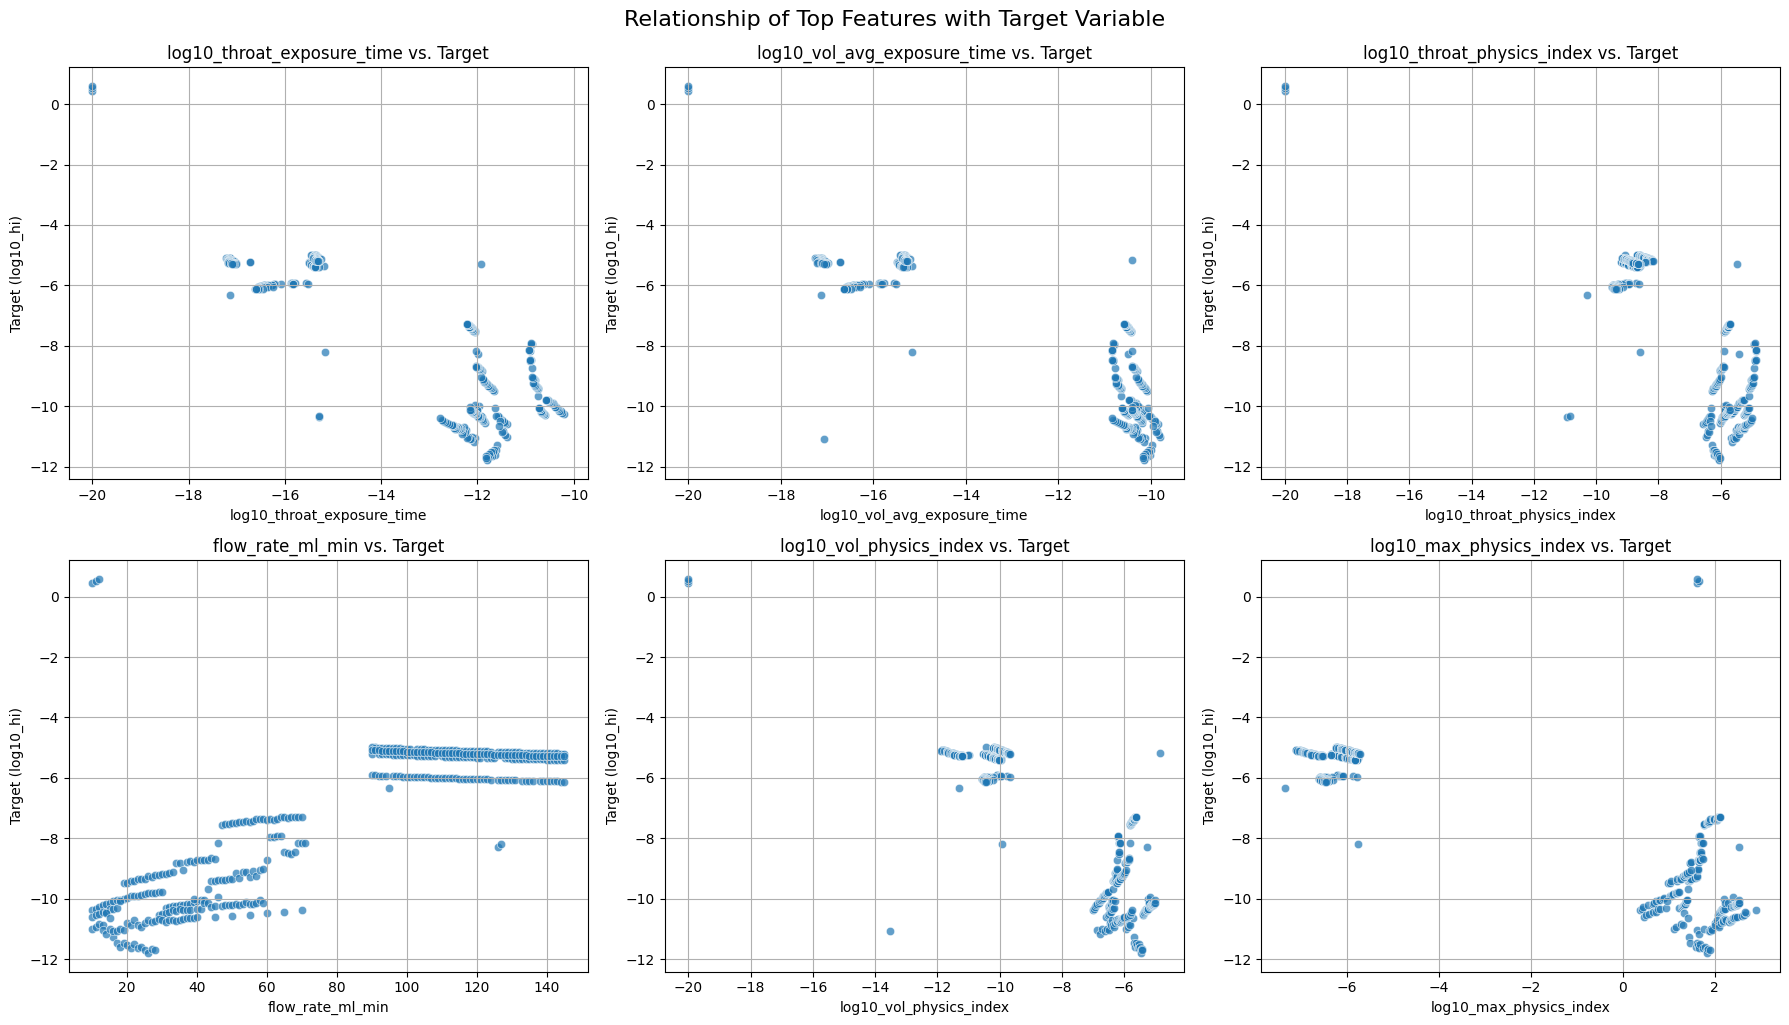

In [25]:
# Using the top features identified earlier

plt.figure(figsize=(18, 10))
for i, col in enumerate(top_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of top features
    sns.scatterplot(x=df_eda[col], y=df_eda['target_log10_hi'], alpha=0.7)
    plt.title(f'{col} vs. Target', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Target (log10_hi)', fontsize=10)
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Relationship of Top Features with Target Variable', y=1.02, fontsize=16)
plt.show()

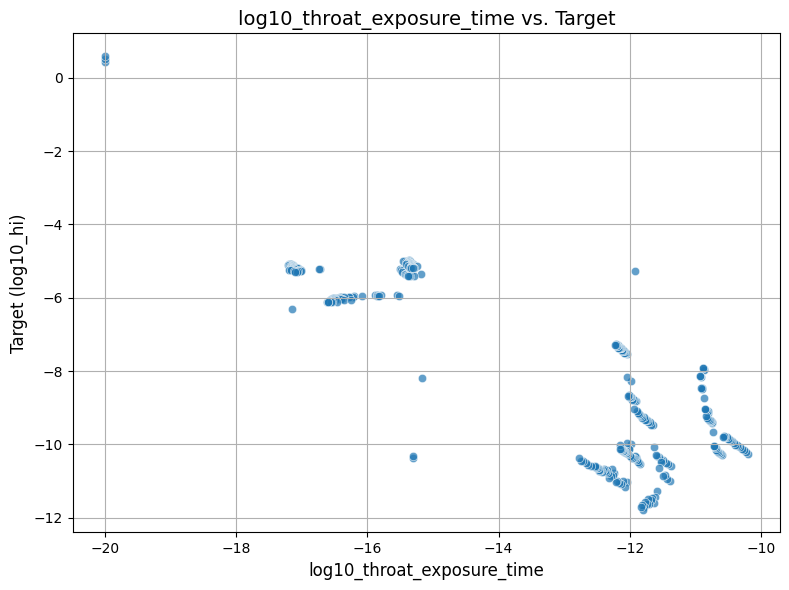

In [40]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_eda['log10_throat_exposure_time'], y=df_eda['target_log10_hi'], alpha=0.7)
plt.title('log10_throat_exposure_time vs. Target', fontsize=14)
plt.xlabel('log10_throat_exposure_time', fontsize=12)
plt.ylabel('Target (log10_hi)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### 2.4 Descriptive Statistics of Numerical Features

In [26]:
# Display descriptive statistics for numerical columns in the features DataFrame (X)
display(X.describe().T)

# Also, show descriptive statistics for the target variable (y)
print("\nDescriptive Statistics for Target Variable (target_log10_hi):")
display(y.describe())

,count,mean,std,min,25%,50%,75%,max
flow_rate_ml_min,427.0,77.901639,43.478554,10.000000,36.000000,90.000000,117.500000,145.000000
inlet_diameter_mm,427.0,1.469321,0.247940,1.000000,1.600000,1.600000,1.600000,1.600000
hydraulic_diameter_mm,427.0,1.681991,0.706735,0.430000,2.080000,2.080000,2.080000,2.080000
log10_vol_avg_exposure_time,427.0,-13.318355,2.936564,-20.000000,-15.838695,-15.267598,-10.397941,-9.795880
log10_max_exposure_time,427.0,-11.470913,4.630830,-17.190440,-15.653785,-15.182428,-6.786484,-6.590067
log10_throat_exposure_time,427.0,-13.936915,2.376877,-20.000000,-15.846286,-15.300154,-11.897940,-10.200659
log10_vol_physics_index,427.0,-8.380534,2.533049,-20.000000,-10.395786,-9.716699,-6.078602,-4.841638
log10_throat_physics_index,427.0,-7.388704,1.983149,-20.000000,-8.879476,-8.216811,-5.743538,-4.850781
log10_max_physics_index,427.0,-2.349424,4.037888,-7.353596,-6.274909,-5.744727,1.679261,2.911126
log10_vol_avg_shear_rate,427.0,2.479357,0.370533,1.391998,2.222192,2.553241,2.751747,3.091640



Descriptive Statistics for Target Variable (target_log10_hi):


,target_log10_hi
count,427.000000
mean,-7.464437
std,2.407213
min,-11.787369
25%,-10.059593
50%,-6.112362
75%,-5.241107
max,0.597266


### 2.5 Analysis of Categorical Features (One-Hot Encoded)

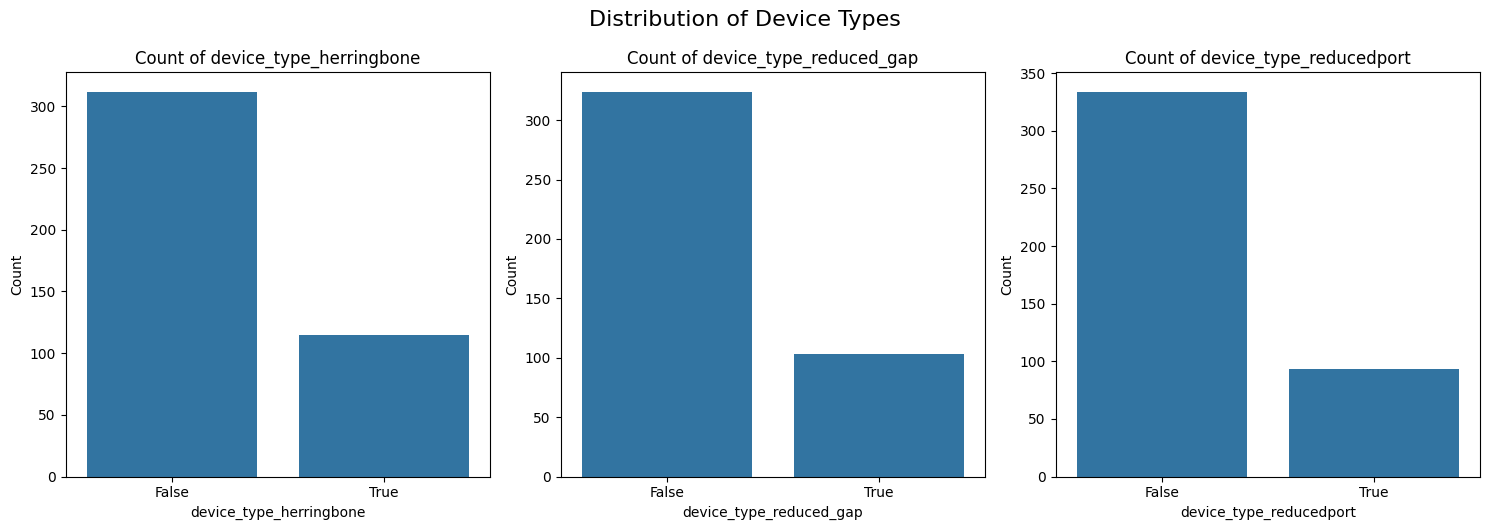

In [27]:
categorical_cols = ['device_type_herringbone', 'device_type_reduced_gap', 'device_type_reducedport']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1) # Adjust subplot grid
    sns.countplot(x=df_eda[col])
    plt.title(f'Count of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
plt.tight_layout()
plt.suptitle('Distribution of Device Types', y=1.05, fontsize=16)
plt.show()

### 2.6 Outlier Detection with Box Plots

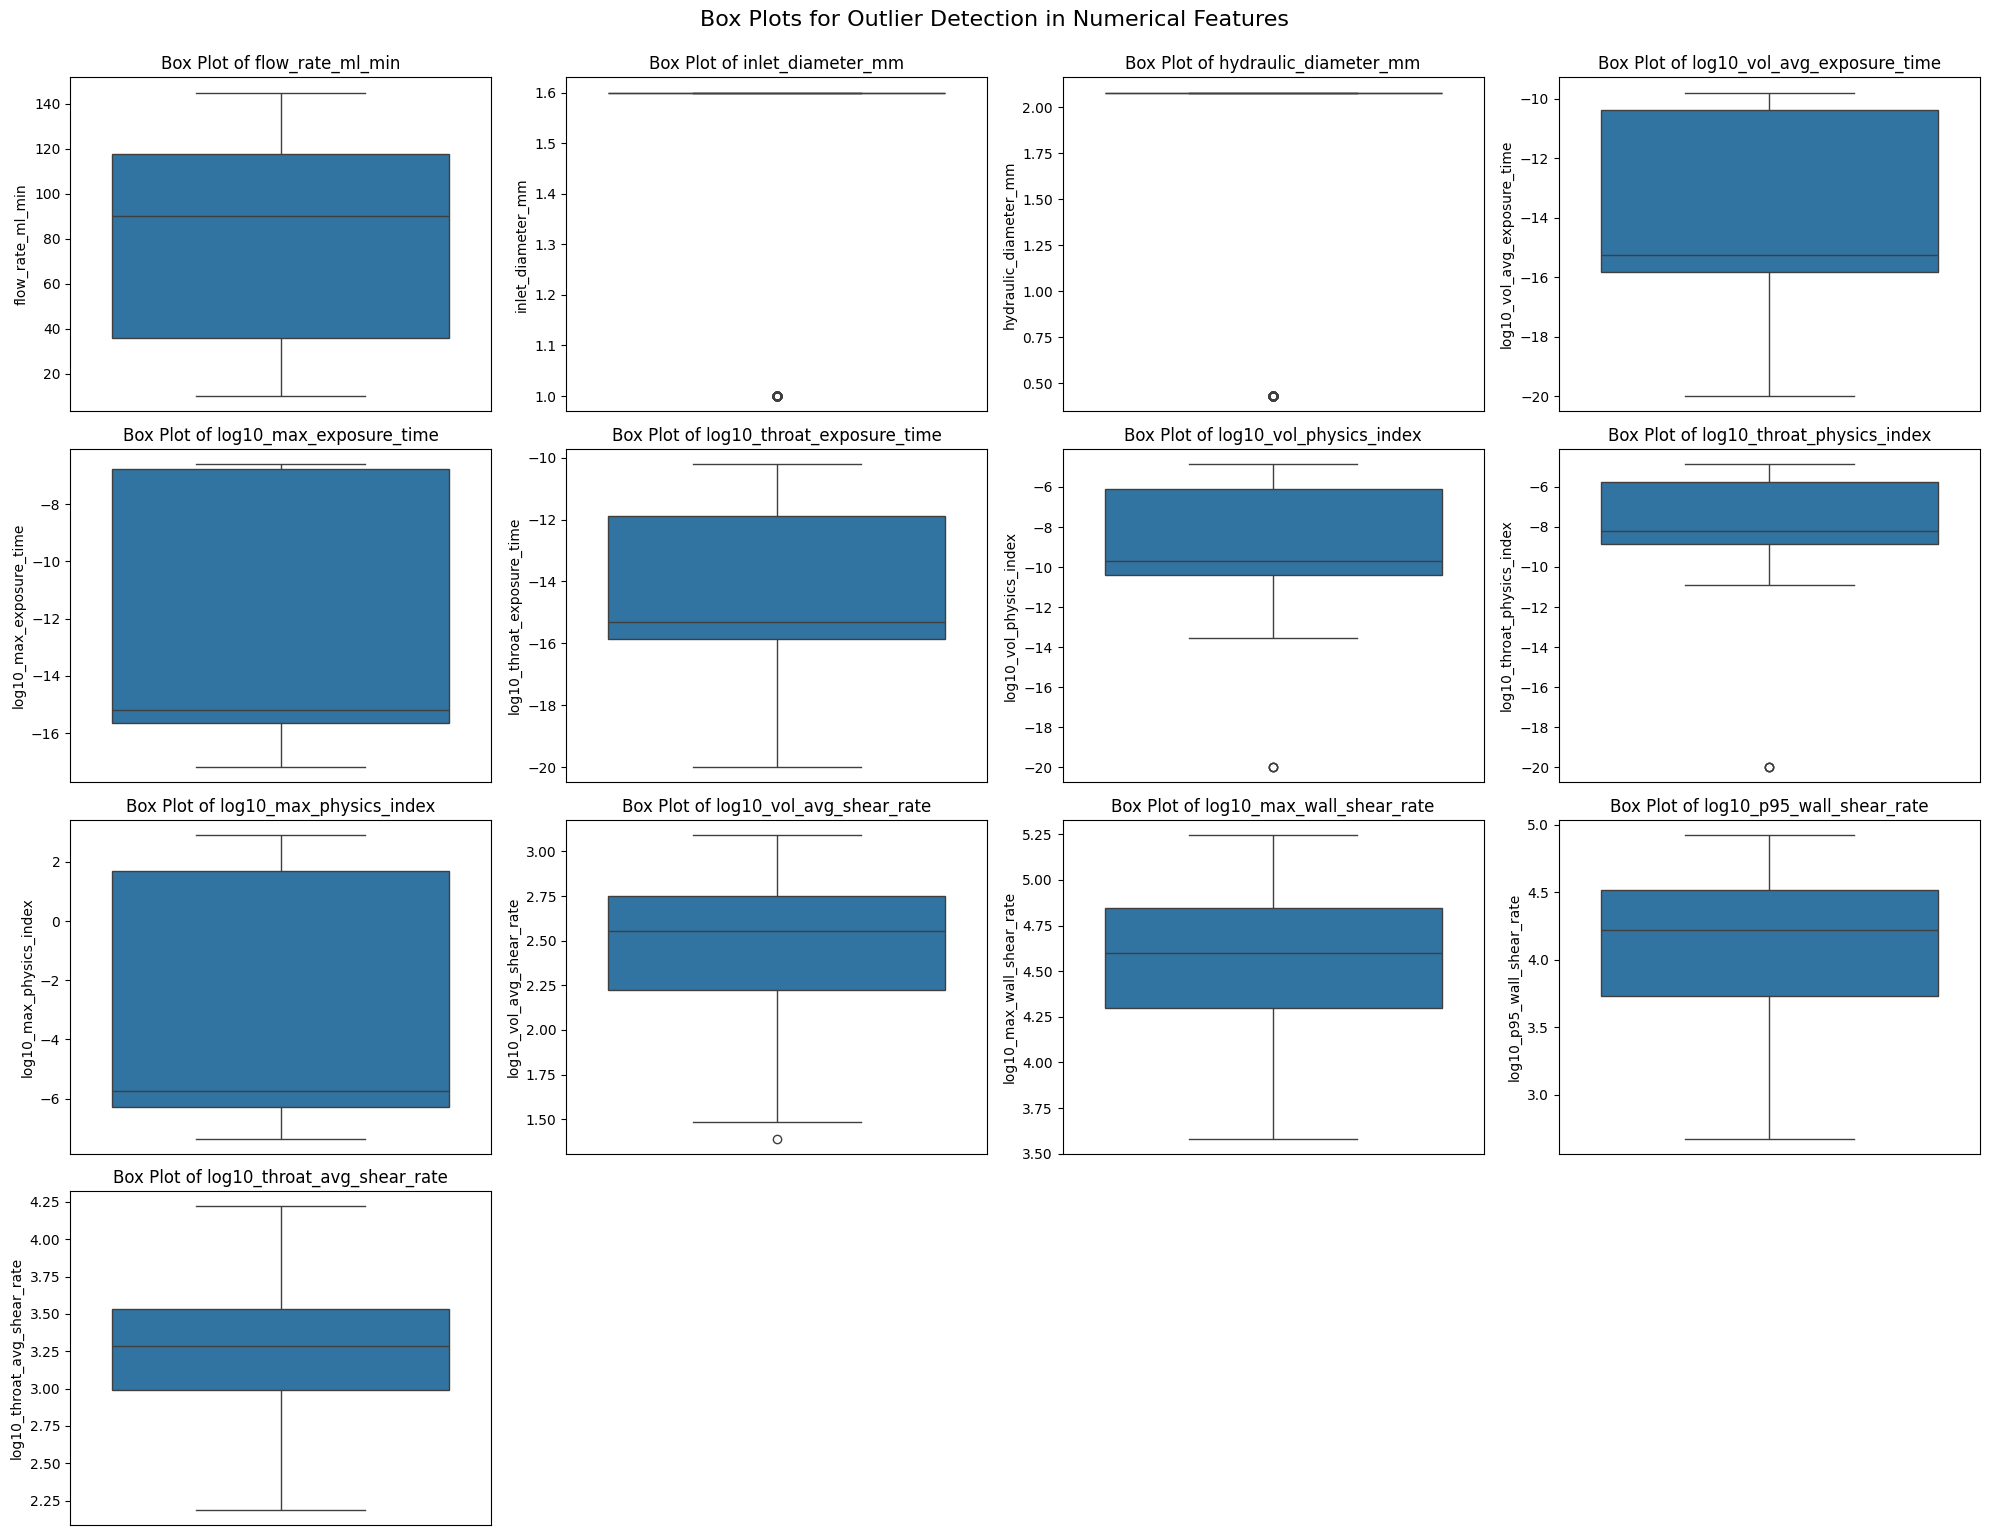

In [28]:
# Using the numerical features from X (excluding the one-hot encoded columns, as their distribution is already covered)
numerical_for_boxplot = X.select_dtypes(include=np.number).columns.tolist()
# Remove the one-hot encoded columns if they were included by select_dtypes
numerical_for_boxplot = [col for col in numerical_for_boxplot if col not in categorical_cols]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_for_boxplot):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid
    sns.boxplot(y=X[col])
    plt.title(f'Box Plot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.xticks([]) # Hide x-axis ticks for single box plots
plt.tight_layout()
plt.suptitle('Box Plots for Outlier Detection in Numerical Features', y=1.02, fontsize=16)
plt.show()

### 2.7 Checking for Missing Values

In [30]:
# Check for missing values in the combined DataFrame (df_eda which includes features and target)
missing_values = df_eda.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing Values by Column:")
    display(missing_values.sort_values(ascending=False))

    # Optionally, visualize missing values
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
    plt.title('Missing Values Count by Feature', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

No missing values found in the dataset.


## 3. Data Preprocessing and Feature Engineering

In [13]:
# Add a small number to handle zeros during log transformation
epsilon = 1e-20

# List of columns to transform
skewed_cols = ['vol_avg_exposure_time', 'max_exposure_time', 'throat_exposure_time',
               'vol_physics_index', 'throat_physics_index', 'max_physics_index',
               'vol_avg_shear_rate', 'max_wall_shear_rate', 'p95_wall_shear_rate', 'throat_avg_shear_rate']

# Apply log transformation
for col in skewed_cols:
    df[f'log10_{col}'] = np.log10(df[col] + epsilon)

# Drop the original skewed columns
df = df.drop(columns=skewed_cols)

# Convert 'device_type' (text column) into numerical (0, 1) using one-hot encoding for Machine Learning
df = pd.get_dummies(df, columns=['device_type'], drop_first=True)

print("Features after cleaning:")
display(df.head())

Features after cleaning:


,flow_rate_ml_min,inlet_diameter_mm,hydraulic_diameter_mm,target_log10_hi,log10_vol_avg_exposure_time,log10_max_exposure_time,log10_throat_exposure_time,log10_vol_physics_index,log10_throat_physics_index,log10_max_physics_index,log10_vol_avg_shear_rate,log10_max_wall_shear_rate,log10_p95_wall_shear_rate,log10_throat_avg_shear_rate,device_type_herringbone,device_type_reduced_gap,device_type_reducedport
0,10,1.6,2.08,-10.364940,-10.018181,-6.793174,-15.300154,-7.008331,-10.924453,0.373032,1.504833,3.583103,3.552681,2.188253,False,False,False
1,11,1.6,2.08,-10.325546,-10.057496,-6.832683,-15.300154,-6.966576,-10.841638,0.416422,1.546263,3.624552,3.594074,2.229550,False,False,False
2,12,1.6,2.08,-10.264360,-10.093665,-6.872895,-10.200659,-6.924453,-5.665546,0.451881,1.584092,3.662388,3.631862,2.267260,False,False,False
3,13,1.6,2.08,-10.216936,-10.126679,-6.844664,-10.234331,-6.889410,-5.630784,0.549716,1.618886,3.697190,3.666625,2.302001,False,False,False
4,14,1.6,2.08,-10.164675,-10.158015,-6.798603,-10.266001,-6.856985,-5.596879,0.660221,1.651110,3.729412,3.698809,2.334143,False,False,False


### 3.2 Handling Skewed Distributions and Categorical Features

### 3.1 Restructuring Data Preprocessing into a Module

In [14]:
from sklearn.model_selection import train_test_split

# Separate the target column
y = df['target_log10_hi']
X = df.drop(columns=['target_log10_hi'])

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (341, 16)
Testing data size: (86, 16)


## 4. Data Splitting: Training and Testing Sets

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model RMSE (Error): {rmse:.4f}")
print(f"Model Accuracy (R2 Score): {r2:.4f} (1.0 is the best possible score)")

Model RMSE (Error): 0.2792
Model Accuracy (R2 Score): 0.9846 (1.0 is the best possible score)


## 5. Model Training and Evaluation (Initial)

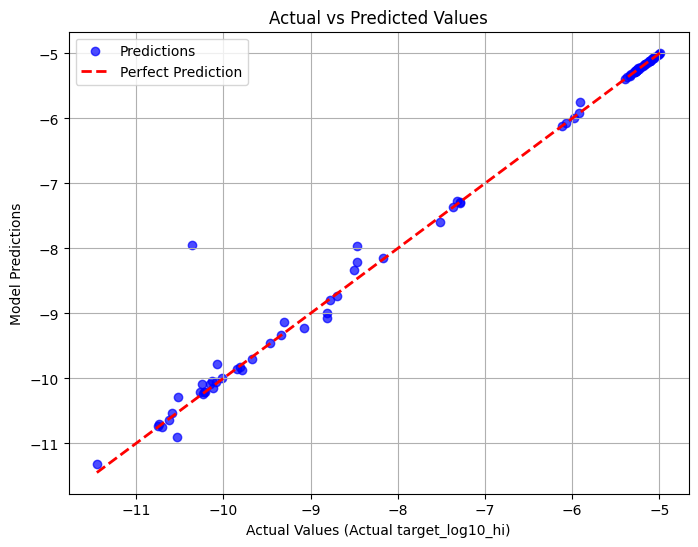

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='Predictions')

# A straight line representing Perfect Prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values (Actual target_log10_hi)')
plt.ylabel('Model Predictions')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

### 5.1 Visualizing Model Performance: Actual vs. Predicted Values

/tmp/ipykernel_1548/3471117526.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


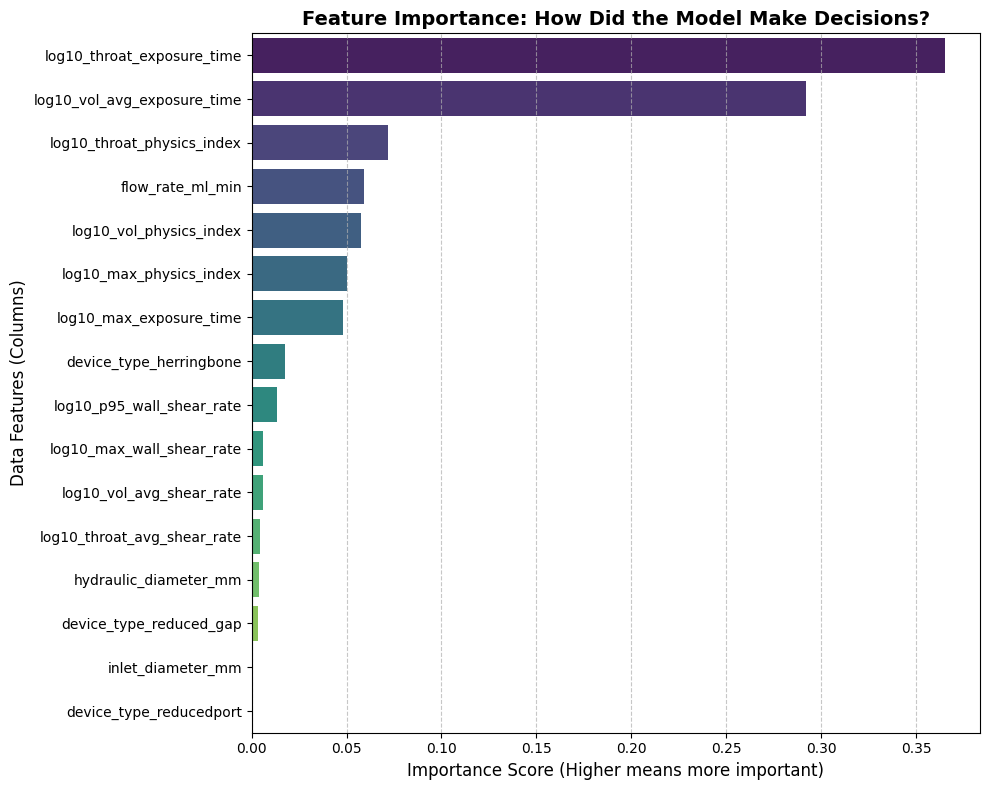

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances from the model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame to organize the data
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance to place the most important features at the top
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create a Horizontal Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Make the graph beautiful and easy to understand
plt.title('Feature Importance: How Did the Model Make Decisions?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Higher means more important)', fontsize=12)
plt.ylabel('Data Features (Columns)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

In [18]:
# 1. Select only the most important (top) features identified in the graph
top_features = [
    'log10_throat_exposure_time',
    'log10_vol_avg_exposure_time',
    'log10_throat_physics_index',
    'flow_rate_ml_min',
    'log10_vol_physics_index',
    'log10_max_physics_index'
]

### 6.1 Selecting Top Features for Model Optimization

In [19]:
# X will now only contain these selected top features (redundant columns dropped)
X_optimized = X[top_features]

# 2. Split the data again into Training and Testing sets
X_train_opt, X_test_opt, y_train, y_test = train_test_split(
    X_optimized, y, test_size=0.2, random_state=42
)

print(f"The old model had {X.shape[1]} columns.")
print(f"The new Optimized model has only {X_optimized.shape[1]} columns!\n")

The old model had 16 columns.
The new Optimized model has only 6 columns!



## 7. Training an Optimized Model with Selected Features

In [20]:
# 3. Train the new Optimized Model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train_opt, y_train)

RandomForestRegressor(random_state=42)

### 7.1 Evaluating the Optimized Model

In [21]:
# 4. Check the results to see the difference in performance
y_pred_opt = final_model.predict(X_test_opt)
r2_opt = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"Optimized Model Accuracy (R2): {r2_opt:.4f}")
print(f"Optimized Model RMSE (Error): {rmse_opt:.4f}\n")

Optimized Model Accuracy (R2): 0.9894
Optimized Model RMSE (Error): 0.2314



## 8. Model Deployment: Saving the Optimized Model

In [22]:
import joblib

# 5. Save the model for Production (.pkl file)
joblib.dump(final_model, 'blood_damage_model_optimized.pkl')
print("Congratulations! The model has been successfully saved as 'blood_damage_model_optimized.pkl'.")

Congratulations! The model has been successfully saved as 'blood_damage_model_optimized.pkl'.
